In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

SAVE_DIR = "/content/drive/MyDrive/LSTM_Demo"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f"{SAVE_DIR}/figures", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/models", exist_ok=True)

print(f"Save directory: {SAVE_DIR}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Save directory: /content/drive/MyDrive/LSTM_Demo
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
DATA_PATH = '/content/drive/MyDrive/dataset_new/Mal-API-2019/all_analysis_data.txt'
LABELS_PATH = '/content/drive/MyDrive/dataset_new/Mal-API-2019/labels.csv'

In [4]:
malware_calls_df = pd.read_csv(DATA_PATH, sep="\t", header=None, names=["API_Calls"])
malware_labels_df = pd.read_csv(LABELS_PATH, header=None, names=["API_Labels"])
malware_calls_df["API_Labels"] = malware_labels_df["API_Labels"]

print(f"Total samples: {len(malware_calls_df)}")
print(f"Malware classes: {malware_calls_df['API_Labels'].nunique()}")
print(f"\nClass distribution:\n{malware_calls_df['API_Labels'].value_counts()}")
malware_calls_df.head()

Total samples: 7107
Malware classes: 8

Class distribution:
API_Labels
Trojan        1001
Backdoor      1001
Downloader    1001
Worms         1001
Virus         1001
Dropper        891
Spyware        832
Adware         379
Name: count, dtype: int64


,API_Calls,API_Labels
0,ldrloaddll ldrgetprocedureaddress ldrloaddll l...,Trojan
1,getsystemtimeasfiletime ntallocatevirtualmemor...,Trojan
2,ldrgetdllhandle ldrgetprocedureaddress getsyst...,Backdoor
3,ldrloaddll ldrgetprocedureaddress ldrloaddll l...,Backdoor
4,ldrloaddll ldrgetprocedureaddress ldrgetproced...,Trojan


In [ ]:
vn_labels = {
    'Trojan': 'Trojan\n(Mã độc ngựa thành Troy)',
    'Backdoor': 'Backdoor\n(Cửa hậu)',
    'Downloader': 'Downloader\n(Trình tải xuống)',
    'Worms': 'Worms\n(Sâu máy tính)',
    'Virus': 'Virus\n(Vi-rút)',
    'Dropper': 'Dropper\n(Trình cài mã độc)',
    'Spyware': 'Spyware\n(Phần mềm gián điệp)',
    'Adware': 'Adware\n(Phần mềm quảng cáo)',
}

counts = malware_calls_df['API_Labels'].value_counts()
labels_vn = [vn_labels[c] for c in counts.index]

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#a8d8ea', '#aa96da', '#fcbad3', '#ffffd2', '#b5eead', '#f3a683', '#f7d794', '#778beb']
bars = ax.barh(labels_vn, counts.values, color=colors, height=0.7, edgecolor='grey', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, f'{val:,}',
            va='center', fontsize=13, fontweight='bold')
ax.set_xlabel('Số lượng mẫu', fontsize=14)
ax.set_title('Phân phối các lớp mã độc trong tập dữ liệu Mal-API-2019', fontsize=15, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.set_xlim(0, max(counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {SAVE_DIR}/figures/class_distribution.png")

In [6]:
# Bài báo: 342 unique API calls, input_length = 342 (Figure 5, page 14)
MAX_LEN = 342

X = malware_calls_df["API_Calls"]

le = LabelEncoder()
Y = le.fit_transform(malware_calls_df["API_Labels"])
num_classes = len(le.classes_)
class_names = list(le.classes_)
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

tok = Tokenizer()
tok.fit_on_texts(X)
vocab_size = len(tok.word_index) + 1
print(f"Found {len(tok.word_index)} unique tokens, vocab_size={vocab_size}")

X_seq = tok.texts_to_sequences(X.values)
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN)
print(f"Shape of data tensor: {X_pad.shape}")

# 80/20 split (Algorithm 1, page 11)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_pad, Y, test_size=0.20, random_state=42, stratify=Y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

Classes: ['Adware', 'Backdoor', 'Downloader', 'Dropper', 'Spyware', 'Trojan', 'Virus', 'Worms']
Number of classes: 8
Found 280 unique tokens, vocab_size=281
Shape of data tensor: (7107, 342)

Train set: 5685 samples
Test set:  1422 samples


In [8]:
def build_binary_model(vocab_size, max_len, act_func='softsign'):
    """
    Binary LSTM model theo Figure 5 (page 14):
    Embedding(16) -> LSTM(100, return_seq=True) -> Dropout -> LSTM(100) -> Flatten -> Dense(2)
    """
    model = Sequential([
        Embedding(vocab_size, 16, input_length=max_len),
        LSTM(100, activation=act_func, return_sequences=True,
             recurrent_activation='sigmoid'),   # giữ gate activation = sigmoid (mặc định)
        Dropout(0.2),
        LSTM(100, activation=act_func,
             recurrent_activation='sigmoid'),
        Flatten(),
        Dense(2, activation='softmax')
    ])
    return model

# Bài báo (page 13): "We used tanh, relu, sigmoid, softplus, softsign, softmax and linear
# activation functions and created eight different models for each malware class."
activation_funcs = ['tanh', 'relu', 'sigmoid', 'softplus', 'softsign', 'softmax', 'linear']

binary_results = {}

for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*60}")
    print(f"Training binary model for: {class_name} (class {class_idx})")
    print(f"{'='*60}")

    Y_binary = (Y_train == class_idx).astype(int)
    Y_binary_test = (Y_test == class_idx).astype(int)
    Y_binary_cat = to_categorical(Y_binary, 2)
    Y_binary_test_cat = to_categorical(Y_binary_test, 2)

    best_f1 = -1
    best_act = None
    best_model = None
    best_history = None

    for act_func in activation_funcs:
        print(f"  {act_func:10s}", end=" -> ")
        tf.keras.backend.clear_session()

        model = build_binary_model(vocab_size, MAX_LEN, act_func)
        model.compile(
            loss='categorical_crossentropy',
            optimizer=tf.keras.optimizers.Adam(clipnorm=1.0),  # gradient clipping chống explode
            metrics=['accuracy']
        )

        es = EarlyStopping(monitor='val_loss', patience=8,
                          restore_best_weights=True, verbose=0)

        history = model.fit(
            X_train, Y_binary_cat,
            batch_size=64,
            epochs=80,
            validation_data=(X_test, Y_binary_test_cat),
            callbacks=[es], verbose=0
        )

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        report = classification_report(Y_binary_test, y_pred, output_dict=True, zero_division=0)
        f1 = report['1']['f1-score']
        acc = report['accuracy']
        prec = report['1']['precision']
        rec = report['1']['recall']
        print(f"Acc={acc:.3f}, P={prec:.2f}, R={rec:.2f}, F1={f1:.3f}" +
              (" ⚠️ model không học được" if f1 == 0 else ""))

        if f1 > best_f1:
            best_f1 = f1
            best_act = act_func
            best_model = model
            best_history = history

    y_pred_best = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
    report_best = classification_report(Y_binary_test, y_pred_best, output_dict=True, zero_division=0)

    binary_results[class_name] = {
        'accuracy': report_best['accuracy'],
        'precision': report_best['1']['precision'],
        'recall': report_best['1']['recall'],
        'f1': report_best['1']['f1-score'],
        'activation': best_act,
        'history': best_history
    }

    best_model.save(f"{SAVE_DIR}/models/binary_{class_name}.keras")
    print(f"  >>> BEST: {best_act}, F1={best_f1:.3f}")

print("\n✅ Binary classification complete!")


Training binary model for: Adware (class 0)
  tanh       -> Acc=0.981, P=0.92, R=0.71, F1=0.800
  relu       -> 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Acc=0.947, P=0.00, R=0.00, F1=0.000 ⚠️ model không học được
  sigmoid    -> 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Acc=0.984, P=0.96, R=0.72, F1=0.827
  softplus   -> 

...

Acc=0.875, P=0.63, R=0.26, F1=0.369
  softmax    -> 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Acc=0.859, P=0.00, R=0.00, F1=0.000 ⚠️ model không học được
  linear     -> 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Acc=0.859, P=0.00, R=0.00, F1=0.000 ⚠️ model không học được
  >>> BEST: tanh, F1=0.483

✅ Binary classification complete!


In [ ]:

print("=" * 90)
print(f"{'':12s} {'Adware':>10s} {'Backdoor':>10s} {'Downloader':>12s} {'Dropper':>10s} "
      f"{'Spyware':>10s} {'Trojan':>10s} {'Virus':>10s} {'Worm':>10s}")
print("=" * 90)

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    row = f"{metric.capitalize():12s}"
    for cn in class_names:
        row += f" {binary_results[cn][metric]:>10.3f}"
    print(row)

row = f"{'Func.':12s}"
for cn in class_names:
    row += f" {binary_results[cn]['activation']:>10s}"
print(row)
print("=" * 90)

# Save table as CSV
df_binary = pd.DataFrame(binary_results).T
df_binary.to_csv(f"{SAVE_DIR}/binary_classification_results.csv")
print(f"\nSaved: {SAVE_DIR}/binary_classification_results.csv")

                 Adware   Backdoor   Downloader    Dropper    Spyware     Trojan      Virus       Worm
Accuracy          0.984      0.869      0.925      0.892      0.886      0.550      0.933      0.873
Precision         0.965      0.564      0.797      0.662      0.593      0.127      0.914      0.568
Recall            0.724      0.310      0.630      0.287      0.096      0.375      0.582      0.420
F1                0.827      0.400      0.704      0.400      0.165      0.190      0.711      0.483
Func.           sigmoid   softsign   softsign   softsign   softsign   softplus   softsign       tanh

Saved: /content/drive/MyDrive/LSTM_Demo/binary_classification_results.csv


In [7]:
def build_single_lstm(vocab_size, max_len, num_classes):
    """Single layer LSTM - Figure 6, Table 3 (page 16-17)"""
    model = Sequential()
    model.add(tf.keras.layers.Input(shape=(max_len,)))
    model.add(Embedding(vocab_size, 32))
    model.add(LSTM(200, activation='sigmoid',
                   kernel_initializer='glorot_uniform',
                   dropout=0.2))
    model.add(Dense(num_classes, activation='softmax'))
    return model

# Prepare multiclass labels
Y_train_enc = to_categorical(Y_train, num_classes)
Y_test_enc = to_categorical(Y_test, num_classes)

# Build & train
tf.keras.backend.clear_session()
model_1lstm = build_single_lstm(vocab_size, MAX_LEN, num_classes)
model_1lstm.summary()

model_1lstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history_1lstm = model_1lstm.fit(
    X_train, Y_train_enc,
    batch_size=128, epochs=100,
    validation_data=(X_test, Y_test_enc),
    callbacks=[es],
    verbose=1
)

model_1lstm.save(f"{SAVE_DIR}/models/single_lstm_multiclass.keras")
print(f"\nModel saved: {SAVE_DIR}/models/single_lstm_multiclass.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 342, 32)        │         8,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200)            │       186,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,608 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,000 (769.53 KB)

 Trainable params: 197,000 (769.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 217ms/step - accuracy: 0.1425 - loss: 2.0600 - val_accuracy: 0.1575 - val_loss: 2.0401
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1690 - loss: 2.0316 - val_accuracy: 0.1681 - val_loss: 2.0024
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.2056 - loss: 1.9927 - val_accuracy: 0.2138 - val_loss: 1.9550
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.2267 - loss: 1.9565 - val_accuracy: 0.2707 - val_loss: 1.9122
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.2412 - loss: 1.9266 - val_accuracy: 0.2229 - val_loss: 1.8948
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2443 - loss: 1.9080 - val_accuracy: 0.2651 - val_loss: 1.8896
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2786 - loss: 1.8744 - val_accuracy: 0.3045 - val_loss: 1.8348
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3052 - loss: 1.8221 - val_accuracy: 

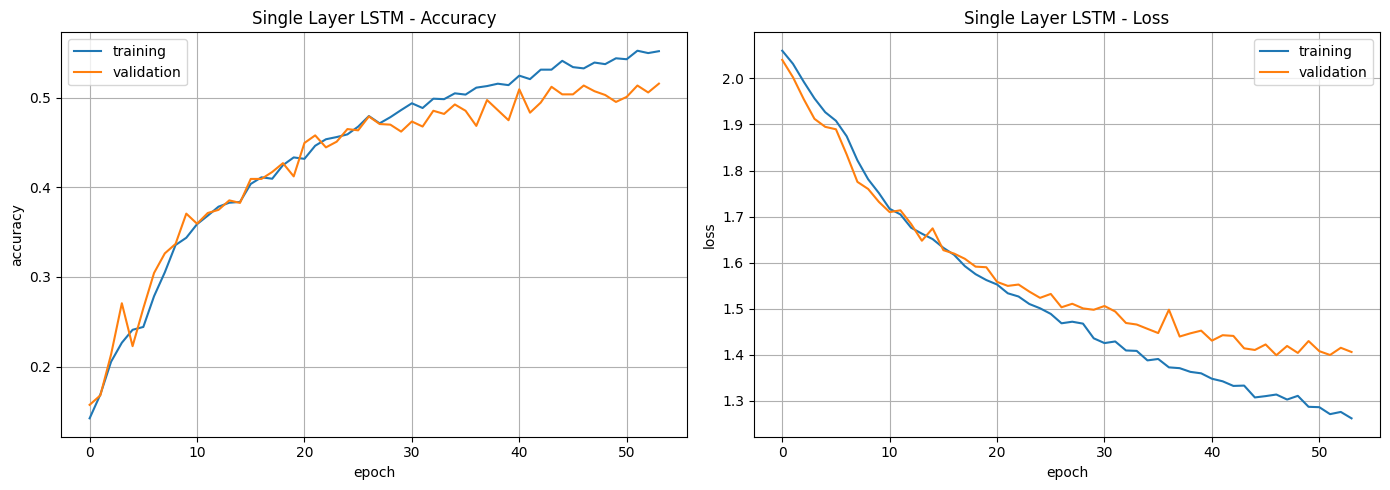

Saved: /content/drive/MyDrive/LSTM_Demo/figures/single_lstm_accuracy_loss.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_1lstm.history['accuracy'], label='training')
ax1.plot(history_1lstm.history['val_accuracy'], label='validation')
ax1.set_title('Single Layer LSTM - Accuracy')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history_1lstm.history['loss'], label='training')
ax2.plot(history_1lstm.history['val_loss'], label='validation')
ax2.set_title('Single Layer LSTM - Loss')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/single_lstm_accuracy_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {SAVE_DIR}/figures/single_lstm_accuracy_loss.png")

45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


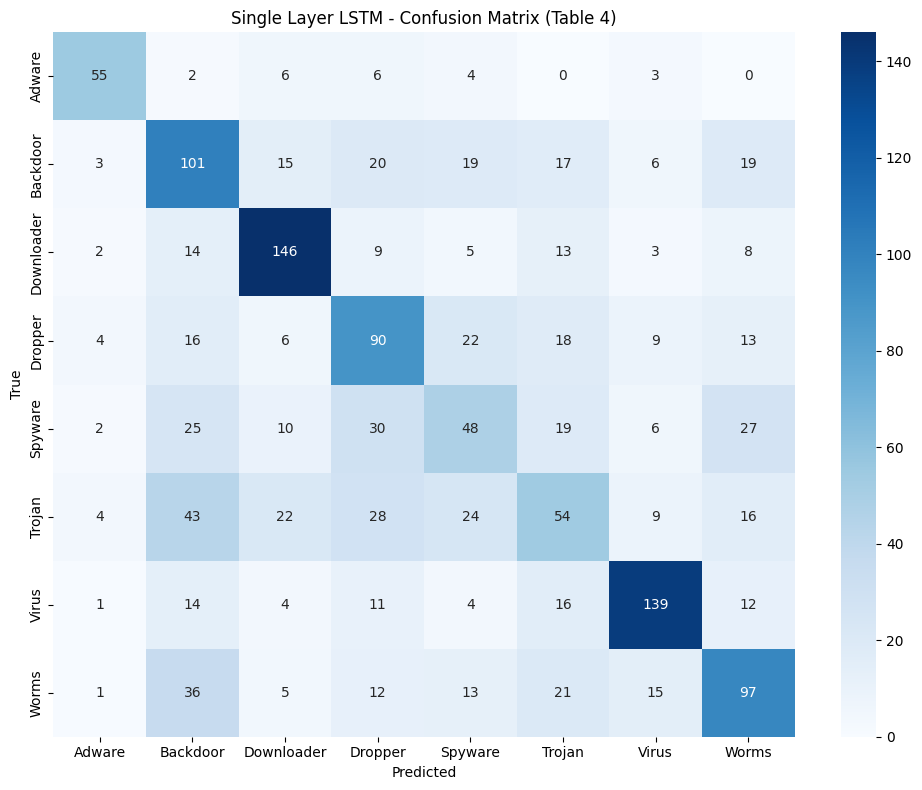


Single Layer LSTM Classification Report (Table 5):
              Precision     Recall         F1
---------------------------------------------
Adware             0.76       0.72       0.74
Backdoor           0.40       0.51       0.45
Downloader         0.68       0.73       0.71
Dropper            0.44       0.51       0.47
Spyware            0.35       0.29       0.31
Trojan             0.34       0.27       0.30
Virus              0.73       0.69       0.71
Worms              0.51       0.48       0.49
---------------------------------------------
Average            0.53       0.52       0.52


In [9]:
y_pred_1lstm = np.argmax(model_1lstm.predict(X_test), axis=1)
cm_1lstm = confusion_matrix(Y_test, y_pred_1lstm)

# Confusion Matrix (Table 4)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_1lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Single Layer LSTM - Confusion Matrix (Table 4)')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/single_lstm_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification Report (Table 5)
print("\nSingle Layer LSTM Classification Report (Table 5):")
print("=" * 55)
report_1lstm = classification_report(Y_test, y_pred_1lstm,
                                      target_names=class_names, output_dict=True)
print(f"{'':12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 45)
for cn in class_names:
    r = report_1lstm[cn]
    print(f"{cn:12s} {r['precision']:>10.2f} {r['recall']:>10.2f} {r['f1-score']:>10.2f}")
avg_p = np.mean([report_1lstm[cn]['precision'] for cn in class_names])
avg_r = np.mean([report_1lstm[cn]['recall'] for cn in class_names])
avg_f = np.mean([report_1lstm[cn]['f1-score'] for cn in class_names])
print("-" * 45)
print(f"{'Average':12s} {avg_p:>10.2f} {avg_r:>10.2f} {avg_f:>10.2f}")

In [10]:
def build_two_layer_lstm(vocab_size, max_len, num_classes):
    """Two layers LSTM - Table 6 (page 18)"""
    model = Sequential()
    model.add(tf.keras.layers.Input(shape=(max_len,)))
    model.add(Embedding(vocab_size, 16))
    model.add(LSTM(25, activation='softsign',
                   kernel_initializer='glorot_uniform',
                   return_sequences=True))
    model.add(LSTM(25, activation='softsign',
                   kernel_initializer='glorot_uniform',
                   recurrent_dropout=0.2))
    model.add(Dense(num_classes, activation='softmax',
                    kernel_regularizer=regularizers.l2(0.01),
                    activity_regularizer=regularizers.l1(0.01)))
    return model

tf.keras.backend.clear_session()
model_2lstm = build_two_layer_lstm(vocab_size, MAX_LEN, num_classes)
model_2lstm.summary()

model_2lstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history_2lstm = model_2lstm.fit(
    X_train, Y_train_enc,
    batch_size=128, epochs=100,
    validation_data=(X_test, Y_test_enc),
    callbacks=[es],
    verbose=1
)

model_2lstm.save(f"{SAVE_DIR}/models/two_lstm_multiclass.keras")
print(f"\nModel saved: {SAVE_DIR}/models/two_lstm_multiclass.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 342, 16)        │         4,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 342, 25)        │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 25)             │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,004 (54.70 KB)

 Trainable params: 14,004 (54.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 342ms/step - accuracy: 0.1523 - loss: 3.4390 - val_accuracy: 0.1632 - val_loss: 3.3929
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.2343 - loss: 3.3558 - val_accuracy: 0.2609 - val_loss: 3.2750
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.2823 - loss: 3.2383 - val_accuracy: 0.3073 - val_loss: 3.1561
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.3024 - loss: 3.1609 - val_accuracy: 0.3052 - val_loss: 3.1192
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.3129 - loss: 3.1266 - val_accuracy: 0.3383 - val_loss: 3.0950
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.3245 - loss: 3.0994 - val_accuracy: 0.3425 - val_loss: 3.0513
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.3333 - loss: 3.0776 - val_accuracy: 0.3439 - val_loss: 3.0577
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.3435 - loss: 3.0725 - val_accuracy: 

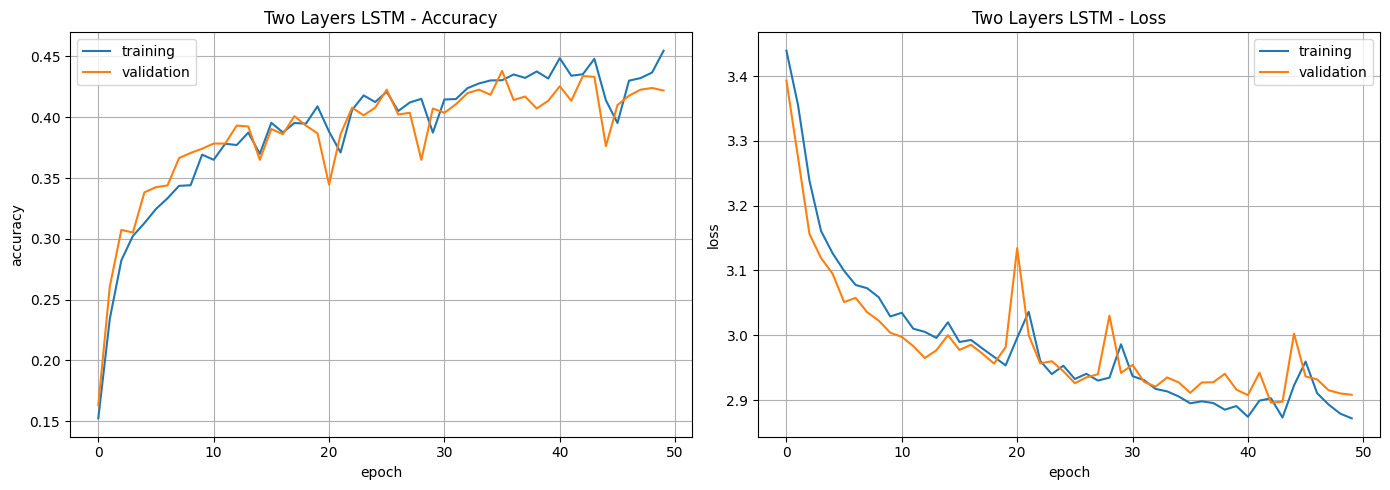

Saved: /content/drive/MyDrive/LSTM_Demo/figures/two_lstm_accuracy_loss.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_2lstm.history['accuracy'], label='training')
ax1.plot(history_2lstm.history['val_accuracy'], label='validation')
ax1.set_title('Two Layers LSTM - Accuracy')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history_2lstm.history['loss'], label='training')
ax2.plot(history_2lstm.history['val_loss'], label='validation')
ax2.set_title('Two Layers LSTM - Loss')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/two_lstm_accuracy_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {SAVE_DIR}/figures/two_lstm_accuracy_loss.png")

45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step


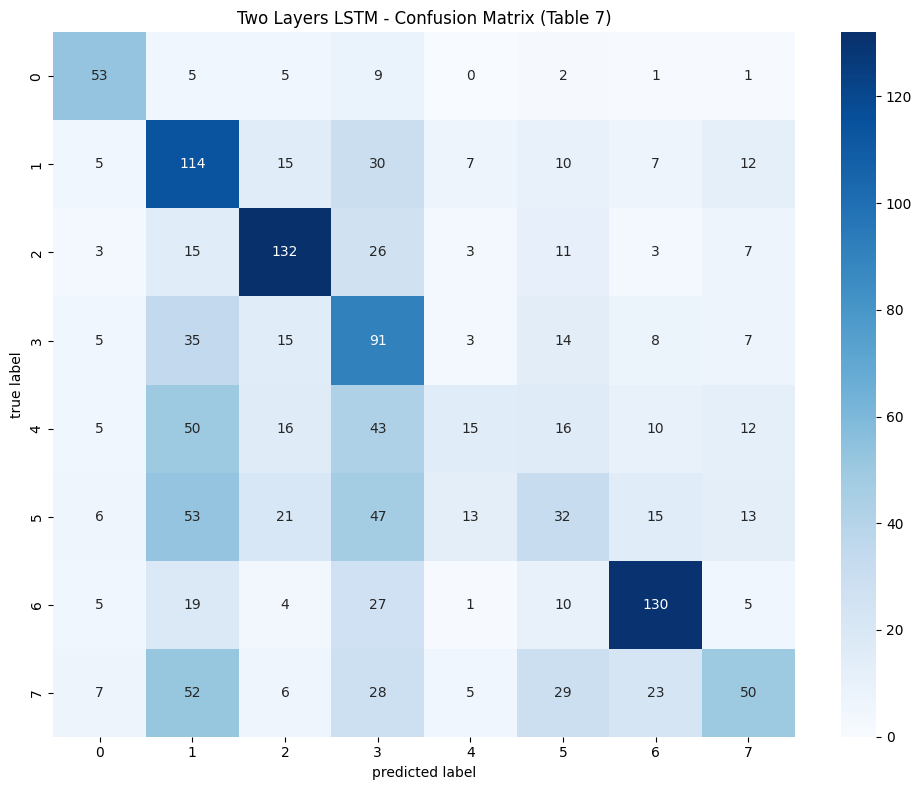


Two Layers LSTM Classification Report (Table 8):
              Precision     Recall         F1
---------------------------------------------
Adware             0.60       0.70       0.64
Backdoor           0.33       0.57       0.42
Downloader         0.62       0.66       0.64
Dropper            0.30       0.51       0.38
Spyware            0.32       0.09       0.14
Trojan             0.26       0.16       0.20
Virus              0.66       0.65       0.65
Worms              0.47       0.25       0.33
---------------------------------------------
Average            0.44       0.45       0.42


In [12]:
y_pred_2lstm = np.argmax(model_2lstm.predict(X_test), axis=1)
cm_2lstm = confusion_matrix(Y_test, y_pred_2lstm)

# Confusion Matrix (Table 7)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_2lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.title('Two Layers LSTM - Confusion Matrix (Table 7)')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/figures/two_lstm_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification Report (Table 8)
print("\nTwo Layers LSTM Classification Report (Table 8):")
print("=" * 55)
report_2lstm = classification_report(Y_test, y_pred_2lstm,
                                      target_names=class_names, output_dict=True)
print(f"{'':12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 45)
for cn in class_names:
    r = report_2lstm[cn]
    print(f"{cn:12s} {r['precision']:>10.2f} {r['recall']:>10.2f} {r['f1-score']:>10.2f}")
avg_p = np.mean([report_2lstm[cn]['precision'] for cn in class_names])
avg_r = np.mean([report_2lstm[cn]['recall'] for cn in class_names])
avg_f = np.mean([report_2lstm[cn]['f1-score'] for cn in class_names])
print("-" * 45)
print(f"{'Average':12s} {avg_p:>10.2f} {avg_r:>10.2f} {avg_f:>10.2f}")

In [13]:
# Table 9: Multi-class classification model performance results
print("\nTable 9: Multi-class classification model performance results")
print("=" * 55)
print(f"{'Model':12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 45)

for name, report in [("LSTM", report_1lstm), ("2LSTM", report_2lstm)]:
    avg_p = np.mean([report[cn]['precision'] for cn in class_names])
    avg_r = np.mean([report[cn]['recall'] for cn in class_names])
    avg_f = np.mean([report[cn]['f1-score'] for cn in class_names])
    print(f"{name:12s} {avg_p:>10.2f} {avg_r:>10.2f} {avg_f:>10.2f}")

print("=" * 55)

# Save all results
results_summary = {
    'single_lstm': {cn: {k: report_1lstm[cn][k] for k in ['precision','recall','f1-score']} for cn in class_names},
    'two_lstm': {cn: {k: report_2lstm[cn][k] for k in ['precision','recall','f1-score']} for cn in class_names},
}
import json as _json
with open(f"{SAVE_DIR}/all_results.json", 'w') as f:
    _json.dump(results_summary, f, indent=2)
print(f"\nAll results saved to: {SAVE_DIR}/all_results.json")


Table 9: Multi-class classification model performance results
Model         Precision     Recall         F1
---------------------------------------------
LSTM               0.53       0.52       0.52
2LSTM              0.44       0.45       0.42

All results saved to: /content/drive/MyDrive/LSTM_Demo/all_results.json


In [14]:
# List all saved files
print("📁 Saved files:")
for root, dirs, files in os.walk(SAVE_DIR):
    level = root.replace(SAVE_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        fpath = os.path.join(root, file)
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"{subindent}{file} ({size_mb:.2f} MB)")

📁 Saved files:
LSTM_Demo/
  binary_classification_results.csv (0.00 MB)
  all_results.json (0.00 MB)
  figures/
    class_distribution.png (0.04 MB)
    single_lstm_accuracy_loss.png (0.10 MB)
    single_lstm_confusion_matrix.png (0.09 MB)
    two_lstm_accuracy_loss.png (0.12 MB)
    two_lstm_confusion_matrix.png (0.07 MB)
  models/
    binary_Adware.keras (1.55 MB)
    binary_Backdoor.keras (1.55 MB)
    binary_Downloader.keras (1.55 MB)
    binary_Dropper.keras (1.55 MB)
    binary_Spyware.keras (1.55 MB)
    binary_Trojan.keras (1.55 MB)
    binary_Virus.keras (1.55 MB)
    binary_Worms.keras (1.55 MB)
    single_lstm_multiclass.keras (2.28 MB)
    two_lstm_multiclass.keras (0.20 MB)
